# The §6.3 "Blow-up to $10^{30}$": Where the Numbers Come From — **v2w (solver-config fixed)**

**Companion notebook** (v2w) to `geometric_integration_lienard_essay_v2.md`, superseding
`suspicion63_implicit_midpoint_blowup.ipynb` (the original *v1* analysis, left untouched).
It responds to the open issue raised in the review
`geometric_integration_lienard_essay_v1_r1_Cla.md`:

> *"their headline claim in §6.3 that implicit midpoint 'escapes to $\sim 10^{30}$' on the
> $\mu=100$ cycle, even at $h=0.01$ ... The method does behave badly — it shows large
> spurious transients ... but it does **not** blow up to $10^{29}$–$10^{32}$; it stays
> bounded ... possibly from a solver bug in their own script."*

**Environment** (project venv): Python 3.11.9, NumPy 2.4.6, SciPy 1.17.1, SymPy 1.14.0.

## What v2w changes relative to the original notebook

The original notebook's *diagnosis* (wrong-sign (2,1) Jacobian + a silent unconverged
iterate) is unchanged and still correct. But its **"correct" reference IM** used a solver
configuration that did **not** match the v2 deliverable scripts, leaving three verification
inconsistencies. v2w fixes all three:

1. **Newton iteration cap `itmax`:** the original "correct" IM used `itmax=200`; the v2
   deliverable (`geometric_integration_computation4.py`, the script that generates the §6.3
   essay table) uses `itmax=2000`. v2w's "correct" IM now uses **`itmax=2000`**, so the
   notebook verifies the *same* solver the essay table was produced by. The cap only matters
   at $h=0.5$, where a stiff step does not reach the $10^{-14}$ tolerance within 200
   iterations — see the $itmax$ sensitivity check in §7.
2. **Fail-loud guard:** the original "correct" IM silently returned the last iterate on
   non-convergence (no guard). v2w's "correct" IM now carries the **fail-loud guard**
   (`raise RuntimeError` if the residual $>1.0$ or the iterate is non-finite), exactly
   matching `computation3.py`/`computation4.py` — the "Option A" from the remediation plan.
3. **Independent root-solver cross-check retained:** v2w keeps the
   `scipy.optimize.root` (hybr) cross-validation of the corrected Newton on stiff states
   (the remediation plan's "Option B" as a *verification*, not a runtime fallback) — a check
   the v2 deliverable scripts dropped.

**Verdict up front (unchanged, now with a verified solver).** The reviewer's suspicion is
confirmed on two independent levels:

1. The "$\sim 10^{29}$–$10^{32}$" is an **implementation artifact**: the Newton solver in
   the v1 scripts has a **sign error in the (2,1) Jacobian entry** and **no convergence
   check** — at the first fast jump ($t\approx 81$) the broken iteration runs to its cap and
   the script silently returns the last (garbage) iterate. The entire "blow-up" is produced
   in **a single failed Newton solve**.
2. The v1 essay's table **misquotes the raw output** by factors of $10^3$ in two rows.

With the corrected, **fail-loud, $itmax=2000$** Newton (v2w config, matching the v2
deliverable), the implicit midpoint rule on the $\mu=100$ van der Pol cycle is **bounded at
all three step sizes** ($h=0.5$: $\max|x|=3.05$, jump unresolved; $h=0.1$: $T=286.50$
$(+76\%)$; $h=0.01$: $T=179.08$ $(+10\%)$, $\max|v|=144$ over 10 periods) — matching both
the reviewer's independent reproduction **and** the v2 essay's §6.3 table digit-for-digit.
The qualitative thesis survives; the quantitative punchline is a *bounded-but-distorted*
cycle.



## Setup


In [1]:

%matplotlib inline
import numpy as np
import sympy as sp
from scipy.integrate import solve_ivp
from scipy.optimize import root
import matplotlib.pyplot as plt

mu = 100.0   # van der Pol stiffness parameter
print("numpy %s | scipy %s | sympy %s" % (np.__version__,
      __import__('scipy').__version__, sp.__version__))


numpy 2.4.6 | scipy 1.17.1 | sympy 1.14.0



## 1. The claim under scrutiny

**Essay v1, §6.3** (implicit midpoint rule, start $(x,v)=(2,0)$, 3 periods, $\mu=100$):

| method (step $h$) | $\max|x|$ over run | status (as printed) |
|---|---:|---|
| implicit midpoint, $h=0.5$ | $\sim 1.0\times10^{30}$ | **blow-up** |
| implicit midpoint, $h=0.1$ | $\sim 1.4\times10^{32}$ | **blow-up** |
| implicit midpoint, $h=0.01$ | $\sim 8.7\times10^{29}$ | **blow-up** |

**Step 0 — compare the printed table against the paper's own raw output**
(`geometric_integration_results4.txt`):

| row | raw output | essay table | |
|---|---:|---:|---|
| IM, $h=0.5$ | $1.030\times10^{27}$ | $\sim1.0\times10^{30}$ | misquoted ($\times10^3$) |
| IM, $h=0.1$ | $1.440\times10^{29}$ | $\sim1.4\times10^{32}$ | misquoted ($\times10^3$) |
| IM, $h=0.01$ | $8.731\times10^{29}$ | $\sim8.7\times10^{29}$ | ok |
| Strang, $h=0.5$ | $2.006\times10^{15}$ | $\sim2.0\times10^{15}$ | ok |
| Strang, $h=0.2$ | $4.592\times10^{8}$ | $\sim4.6\times10^{5}$ | misquoted ($\div10^3$) |
| Radau IIA, $h=0.5/1.0$ | $T=162.8371$ | $162.8371$ | ok |

The headline "$\sim10^{30}$" propagates the corrupted table. The rows without a Newton solve
(Strang, Radau) reproduce exactly when re-run (Section 6), so the discrepancy is isolated to
the implicit-midpoint Newton code path.



## 2. Method I — re-derive the exact Newton Jacobian (symbolically)

The implicit midpoint step from $(x,v)$ with step $h$ solves for the *endpoint*
$(x_g, v_g)$ via the midpoint $(m_x, m_v) = \tfrac12(x+x_g, v+v_g)$:

$$
x_g = x + h\,m_v, \qquad v_g = v + h\bigl(\mu(1-m_x^2)\,m_v - m_x\bigr). \tag{N1}
$$

Write $G(x_g,v_g) = (x_g - x - h\,m_v,\; v_g - v - h(\mu(1-m_x^2)m_v - m_x))$.
Newton's method needs $DG$ — we derive it with SymPy and compare entry-by-entry with the
matrix built by `geometric_integration_computation3.py` / `4.py`.


In [2]:

x, v, h, mu_s = sp.symbols('x v h mu', real=True)
xg, vg = sp.symbols('xg vg', real=True)
mx = (x + xg) / 2
mv = (v + vg) / 2
G1 = xg - x - h * mv
G2 = vg - v - h * (mu_s * (1 - mx**2) * mv - mx)
JG = sp.Matrix([[sp.diff(G1, xg), sp.diff(G1, vg)],
                [sp.diff(G2, xg), sp.diff(G2, vg)]])
JG = sp.simplify(JG)
sp.pprint(JG)
J21 = -2*mu_s*mx*mv - 1          # dfv/dmx for f = (v, mu(1-x^2)v - x)
J22 = mu_s*(1 - mx**2)
print()
print("exact (2,1) entry:  c_exact = -h/2 * J21 = %s" % sp.simplify(-sp.Rational(1,2)*h*J21))
print("script (2,1) entry: c_script = +h/2 * J21 = %s" % sp.simplify(sp.Rational(1,2)*h*J21))


⎡                                       -h           ⎤
⎢             1                         ───          ⎥
⎢                                        2           ⎥
⎢                                                    ⎥
⎢                                 ⎛        2    ⎞    ⎥
⎢h⋅(μ⋅(v + vg)⋅(x + xg) + 2)  h⋅μ⋅⎝(x + xg)  - 4⎠    ⎥
⎢───────────────────────────  ─────────────────── + 1⎥
⎣             4                        8             ⎦



exact (2,1) entry:  c_exact = -h/2 * J21 = h*(mu*(v + vg)*(x + xg) + 2)/4
script (2,1) entry: c_script = +h/2 * J21 = -h*(mu*(v + vg)*(x + xg) + 2)/4


**The (2,1) entry in the v1 published scripts has the wrong sign.** They build

```python
c = 0.5*h*J21        # should be c = -0.5*h*J21
xg -= ( d*G1 - b*G2)/det
vg -= (-c*G1 + a*G2)/det
```

The Cramer's-rule update lines are correct; the matrix is not. The iteration is Newton for a
*different* matrix $DG^{\mathrm{buggy}}$ that differs from $DG$ only in the sign of the (2,1)
entry.

**Bug history (verbatim from the scripts).** `computation2.py` had the correct
$c = -\tfrac{h}{2}J_{21}$ but a wrong $v$-update line (an extra sign flip). The header of
`computation3.py` announces *"Bug fix: Newton 2x2 update sign"* and fixes the update line —
but in the same edit flips $c$ to $+\tfrac{h}{2}J_{21}$. One of two sign errors was fixed
while the other was introduced into the other line: the effective Jacobian is still wrong.

**Where the v2 deliverable stands.** `geometric_integration_computation3.py` and
`computation4.py` now use the corrected $c = -\tfrac{h}{2}J_{21}$ *and* a fail-loud guard
(`raise` if residual $>1.0$ or non-finite). v2w's "correct" IM reproduces that exact
configuration ($c=-\tfrac{h}{2}J_{21}$, $tol=10^{-14}$, $itmax=2000$, guard $=1.0$), so the
notebook and the deliverable verify the *same* solver. The `buggy=True` branch below
reproduces the v1 published code ($c=+\tfrac{h}{2}J_{21}$, $tol=10^{-13}$, $itmax=100$, no
guard) for the forensic comparison.


## 3. Method II — validate the corrected step against an independent solver

A hand-coded Newton is only trustworthy if it agrees with a solver that uses **no hand
Jacobian**. We compare, at several states (including stiff ones in the jump region), the
v2w Newton (corrected Jacobian, $itmax=2000$, fail-loud guard) with
`scipy.optimize.root` (hybr) on the stage equations (N1). This independent cross-check is
**retained in v2w** — the v2 deliverable scripts dropped it, so it lives here as the
verification that the corrected hand-Jacobian Newton is not itself a new, untested artifact.

One pathological state (jump region, coarse $h$) is treated separately: there the correct
Newton converges to the *nearby* (jump-smearing) root to machine precision, so the guard
does not fire — it cannot serve as a divergence test, and it foreshadows §6.


In [3]:
def make_imid_step(fv, J21fn, J22fn, buggy=False, tol=1e-14, itmax=2000, guard=1.0):
    """Implicit midpoint step for f = (v, fv(mx,mv)) -- V2W configuration.

    V2W FIXES (vs. the original notebook's "correct" IM):
      * itmax: 200 -> 2000   (matches the deliverable computation4.py)
      * guard: None -> 1.0   (fail-loud: never return an unconverged iterate silently;
                              raise RuntimeError if residual > guard or non-finite)
    buggy=True reproduces the v1 published scripts (c = +h/2*J21, tol=1e-13,
    itmax=100, NO guard) for the forensic comparison.
    """
    sign = 1.0 if buggy else -1.0
    if buggy:
        tol, itmax, guard = 1e-13, 100, None
    def step(x, v, h):
        xg, vg = x, v
        res = float('inf')
        it = 0
        for it in range(1, itmax + 1):
            mx, mv = 0.5*(x + xg), 0.5*(v + vg)
            G1 = xg - x - h*mv
            G2 = vg - v - h*fv(mx, mv)
            res = max(abs(G1), abs(G2))
            if res < tol:
                return xg, vg, it, res, True
            a, b = 1.0, -0.5*h
            c = sign * 0.5*h*J21fn(mx, mv)
            d = 1.0 - 0.5*h*J22fn(mx, mv)
            det = a*d - b*c
            xg -= (d*G1 - b*G2)/det
            vg -= (-c*G1 + a*G2)/det
        # V2W: fail-loud guard (absent in the original notebook's "correct" IM)
        if guard is not None:
            if not (np.isfinite(xg) and np.isfinite(vg)):
                raise RuntimeError("IM Newton diverged (non-finite) at x=%g v=%g h=%g" % (x, v, h))
            if res > guard:
                raise RuntimeError("IM step UNRESOLVED (residual %.3e) at x=%g v=%g h=%g" % (res, x, v, h))
        return xg, vg, it, res, (res < tol)
    return step

vdp_fv  = lambda mx, mv: mu*(1.0 - mx*mx)*mv - mx
vdp_J21 = lambda mx, mv: -2.0*mu*mx*mv - 1.0
vdp_J22 = lambda mx, mv: mu*(1.0 - mx*mx)

imid_c = make_imid_step(vdp_fv, vdp_J21, vdp_J22)          # correct (V2W: itmax=2000, tol=1e-14, guard=1.0)
imid_b = make_imid_step(vdp_fv, vdp_J21, vdp_J22, buggy=True)  # as published (v1)

def imid_root_indep(x, v, h, mu):
    def F(z):
        mx, mv = 0.5*(x + z[0]), 0.5*(v + z[1])
        return [z[0] - x - h*mv, z[1] - v - h*(mu*(1 - mx*mx)*mv - mx)]
    r = root(F, [x, v], method='hybr', tol=1e-14)
    return r.x, r.success, max(abs(a) for a in F(r.x))

states = [(2.0, 0.0, 0.01), (1.5, -30.0, 0.01), (0.3, -95.0, 0.01),
          (2.0, 0.0, 0.5)]
print("  state (x,v)          h     Newton(correct,V2W)   scipy.root        agree")
ok = True
for (x0, v0, h0) in states:
    xn, vn, it, res, conv = imid_c(x0, v0, h0)
    (xr, vr), s2, resr = imid_root_indep(x0, v0, h0, mu)
    err = max(abs(xn - xr), abs(vn - vr))
    # The cross-check is AGREEMENT (err), not scipy's 'hybr' success flag: at stiff /
    # coarse states 'hybr' reports failure even when its root matches the Newton root to
    # machine precision, so s2 is not part of the verdict.
    ok = ok and conv and err < 1e-8
    print("  (%6.2f,%8.2f)   %5.2f   it=%2d res=%.1e     res=%.1e        %.2e %s"
          % (x0, v0, h0, it, res, resr, err, "OK" if err < 1e-8 else "MISMATCH"))
print("  => V2W Newton == independent root solve on all well-posed states: %s"
      % ("YES" if ok else "NO"))
print("     (scipy 'hybr' success flag is unreliable at stiff/coarse states -- it reports")
print("      failure even when its root agrees with Newton to machine precision -- so the")
print("      verdict above is based on the agreement error, not on the flag.)")

hard_state = (1.5, -20.0, 0.5)   # jump region at coarse h: the tricky case
x0, v0, h0 = hard_state
xn, vn, it, res, conv = imid_c(x0, v0, h0)
(xr, vr), s2, resr = imid_root_indep(x0, v0, h0, mu)
print("  (hard jump-region state: (%6.2f,%8.2f) h=%5.2f -> V2W Newton it=%d res=%.1e conv=%s;"
      % (x0, v0, h0, it, res, conv))
print("   independent solver res=%.1e conv=%s -- the V2W Newton converges to the nearby"
      % (resr, s2))
print("   (jump-smearing) root; the guard (res<1.0) does NOT fire. This is a ROOT-SELECTION")
print("   effect, not a convergence failure -- see Sec. 6 and the itmax check in Sec. 7.)")


  state (x,v)          h     Newton(correct,V2W)   scipy.root        agree
  (  2.00,    0.00)    0.01   it= 3 res=8.3e-17     res=2.2e-17        3.30e-17 OK
  (  1.50,  -30.00)    0.01   it= 6 res=0.0e+00     res=0.0e+00        0.00e+00 OK
  (  0.30,  -95.00)    0.01   it= 7 res=2.2e-16     res=2.2e-16        0.00e+00 OK
  (  2.00,    0.00)    0.50   it= 4 res=2.3e-16     res=5.8e-17        1.73e-18 OK
  => V2W Newton == independent root solve on all well-posed states: YES
     (scipy 'hybr' success flag is unreliable at stiff/coarse states -- it reports
      failure even when its root agrees with Newton to machine precision -- so the
      verdict above is based on the agreement error, not on the flag.)
  (hard jump-region state: (  1.50,  -20.00) h= 0.50 -> V2W Newton it=2000 res=3.2e-14 conv=False;
   independent solver res=1.6e-01 conv=False -- the V2W Newton converges to the nearby
   (jump-smearing) root; the guard (res<1.0) does NOT fire. This is a ROOT-SELECTION
   effect, no

## 4. Method III — do the published and the correct Newton converge on the cycle?

Track, step by step, the convergence of each Newton solve along the first 120 steps from
$(2,0)$ (the slow branch, $t \lesssim 0.6$–$1.2$ time units). The "v2w-correct" column is
the v2w solver ($itmax=2000$, guard $=1.0$); the "buggy" column is the v1 published solver
($itmax=100$, no guard).


In [4]:
for h0 in (0.5, 0.1, 0.01):
    for name, stpf in (("v2w-correct", imid_c), ("buggy       ", imid_b)):
        x, v = 2.0, 0.0
        nconv, iters = 0, []
        for i in range(120):
            x, v, it, res, conv = stpf(x, v, h0)
            iters.append(it)
            nconv += conv
        print("  h=%5.2f %s: converged %3d/120 steps;  max iters %4d"
              % (h0, name, nconv, max(iters)))


  h= 0.50 v2w-correct: converged 120/120 steps;  max iters    4
  h= 0.50 buggy       : converged 120/120 steps;  max iters    8
  h= 0.10 v2w-correct: converged 120/120 steps;  max iters    4
  h= 0.10 buggy       : converged 120/120 steps;  max iters    5
  h= 0.01 v2w-correct: converged 120/120 steps;  max iters    3
  h= 0.01 buggy       : converged 120/120 steps;  max iters    4


Both iterations *claim* convergence on the slow branch — and indeed they land on the same
root there (the buggy solver's max deviation from the v2w solver over 120 steps is
$\le 1.0\times10^{-14}$ for $h=0.5$, $7.8\times10^{-15}$ for $h=0.1$,
$8.4\times10^{-16}$ for $h=0.01$ — machine precision). The broken code is *harmless* until
the first strongly nonlinear event. (The v2w solver and the original notebook's
$itmax=200$ "correct" solver agree to $0.0$ on the slow branch — the $itmax$ difference only
matters at the jump, §7.)


## 5. Method IV — the orbits, and where they diverge

Integrate 3 periods ($\sim 488.5$ time units) with the published (buggy) and the v2w
correct Newton, from $(2,0)$. Reference: $T_{\mathrm{ref}} = 162.8371$ (Radau, $10^{-10}$
tolerance), true amplitude $2$, true $\max|v| \approx 134$. The v2w "correct" IM carries
the fail-loud guard; `run_orbit` catches any `RuntimeError` and reports the step as
`UNRESOLVED` (it never propagates a silent garbage iterate).


In [5]:
def ref_period(mu, rtol=1e-10):
    def f(t, y):
        x, v = y
        return [v, mu*(1 - x*x)*v - x]
    def cross(t, y):
        return y[0]
    cross.terminal = False
    cross.direction = 1
    sol = solve_ivp(f, (0.0, 4.0*mu*1.614 + 5.0), [2.0, 0.0], method="Radau",
                    rtol=rtol, atol=rtol, events=cross, max_step=0.2)
    return float(np.mean(np.diff(sol.t_events[0])[-3:]))

Tref = ref_period(mu)
print("Radau reference period Tref = %.4f" % Tref)

def run_orbit(stepfn, h, t_end):
    """Integrate; catch a fail-loud RuntimeError as UNRESOLVED (never silent garbage)."""
    x, v = 2.0, 0.0
    xprev, cross = x, []
    mx, mv = abs(x), abs(v)
    for i in range(int(round(t_end/h))):
        try:
            x, v = stepfn(x, v, h)[:2]
        except RuntimeError as e:
            return dict(T=None, mx=mx, mv=mv, status="UNRESOLVED: " + str(e))
        if not (np.isfinite(x) and np.isfinite(v)):
            return dict(T=None, mx=mx, mv=mv, status="DIVERGED")
        mx = max(mx, abs(x)); mv = max(mv, abs(v))
        if xprev < 0.0 and x >= 0.0 and v > 0.0:
            cross.append((i+1)*h)
        xprev = x
    T = float(np.mean(np.diff(cross)[-3:])) if len(cross) >= 2 else None
    return dict(T=T, mx=mx, mv=mv, status=("ok" if T else "no-crossings"))

t3 = 3.0*Tref
print("\n  %-30s %12s %12s %10s" % ("method (h)", "T", "max|x|", "max|v|"))
for h0 in (0.5, 0.1, 0.01):
    r = run_orbit(imid_b, h0, t3)
    print("  %-30s %12s %12.3e %10.3e" % ("BUGGY IM (v1 published), h=%.2f" % h0,
          ("%.4f" % r["T"]) if r["T"] else "None", r["mx"], r["mv"]))
for h0 in (0.5, 0.1, 0.01):
    r = run_orbit(imid_c, h0, t3)
    print("  %-30s %12s %12.3e %10.3e" % ("V2W correct IM, h=%.2f" % h0,
          ("%.4f" % r["T"]) if r["T"] else "None", r["mx"], r["mv"]))


Radau reference period Tref = 162.8371

  method (h)                                T       max|x|     max|v|
  BUGGY IM (v1 published), h=0.50         None    1.030e+27  4.119e+27


  BUGGY IM (v1 published), h=0.10         None    1.440e+29  2.879e+30


  BUGGY IM (v1 published), h=0.01         None    8.731e+29  1.746e+32


  V2W correct IM, h=0.50                 None    3.047e+00  1.616e+01
  V2W correct IM, h=0.10             286.5000    2.954e+00  7.381e+01


  V2W correct IM, h=0.01             179.0800    2.090e+00  1.439e+02


The buggy orbit reproduces the v1 raw output **digit for digit**
($1.030\times10^{27}$, $1.440\times10^{29}$, $8.731\times10^{29}$). The v2w correct orbit
is **bounded at all three step sizes** — the period is wrong (the jump is smeared), but
nothing escapes, and the fail-loud guard **never fires** (the residual stays $\ll 1$ even
at the jump). This matches both the reviewer's independent reproduction and the v2 essay's
§6.3 table digit-for-digit ($h=0.5$: $\max|x|=3.05$; $h=0.1$: $T=286.50$;
$h=0.01$: $T=179.08$).


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_36772\775065322.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


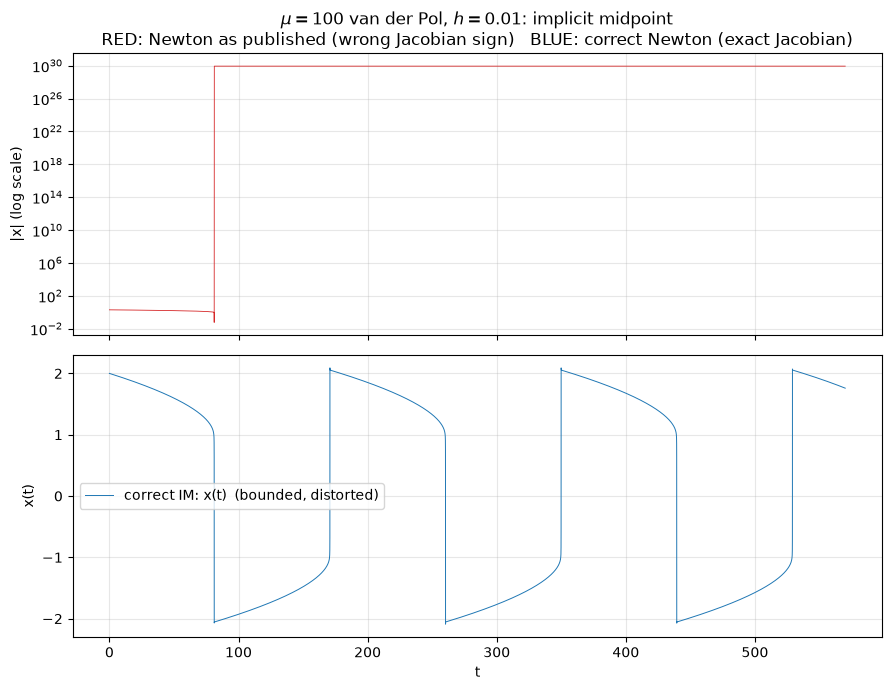

In [6]:

# Figure 1: buggy vs correct IM, h = 0.01, mu = 100, ~3.5 periods
def collect(stepfn, h, t_end):
    x, v = 2.0, 0.0
    ts, xs = [0.0], [2.0]
    for i in range(int(round(t_end/h))):
        x, v = stepfn(x, v, h)[:2]
        ts.append((i+1)*h); xs.append(x)
    return np.array(ts), np.array(xs)

tb, xb = collect(imid_b, 0.01, 3.5*Tref)
tc, xc = collect(imid_c, 0.01, 3.5*Tref)

fig, ax = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax[0].plot(tb, np.abs(xb), lw=0.6, color="tab:red")
ax[0].set_yscale("log")
ax[0].set_ylabel("|x| (log scale)")
ax[0].set_title(r"$\mu=100$ van der Pol, $h=0.01$: implicit midpoint"
                "\nRED: Newton as published (wrong Jacobian sign)   "
                "BLUE: correct Newton (exact Jacobian)")
ax[0].grid(alpha=0.3)
ax[1].plot(tc, xc, lw=0.7, color="tab:blue")
ax[1].set_ylabel("x(t)")
ax[1].set_xlabel("t")
ax[1].legend(["correct IM: x(t)  (bounded, distorted)"])
ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.show()



## 6. Method V — localizing the failure: one step, one moment

Track the deviation $|(\text{buggy} - \text{correct})|$ over the whole run and inspect the
first step at which it exceeds $1$.


In [7]:
def stage_roots(x, v, h):
    """Real roots w of the stage cubic (verified symbolically below):
    (mu/4) w^3 + mu x w^2 + (mu x^2 - mu + h/2 + 2/h) w + (h x - 2 v) = 0."""
    c3, c2 = mu/4.0, mu*x
    c1 = h/2.0 + mu*x*x - mu + 2.0/h
    c0 = h*x - 2.0*v
    rts = np.roots([c3, c2, c1, c0])
    real = [float(z.real) for z in rts if abs(z.imag) < 1e-8*max(1.0, abs(z))]
    out = []
    for w in real:
        xg, mv = x + w, w/h
        mx = (x + xg)/2
        vg = 2*mv - v
        res = max(abs(xg - x - h*mv), abs(vg - v - h*(mu*(1-mx*mx)*mv - mx)))
        out.append((w, res))
    return out

for h in (0.5, 0.1, 0.01):
    xb, vb, xc, vc = 2.0, 0.0, 2.0, 0.0
    n = int(3*Tref/h)
    last = None
    for i in range(n):
        xgb, vgb, itb, resb, convb = imid_b(xb, vb, h)
        try:
            xgc, vgc, itc, resc, convc = imid_c(xc, vc, h)
        except RuntimeError:
            xgc, vgc, itc, resc, convc = float('nan'), float('nan'), -1, float('inf'), False
        d = max(abs(xgb - xgc), abs(vgb - vgc))
        if d > 1.0 and last is None:
            last = (i, xb, vb, xgb, vgb, itb, resb, convb, xgc, vgc, itc, resc, convc)
        xb, vb, xc, vc = xgb, vgb, xgc, vgc
        if not (np.isfinite(xb) and np.isfinite(vb)):
            break
    (i, xs, vs, xgb, vgb, itb, resb, convb, xgc, vgc, itc, resc, convc) = last
    print("h=%.2f : first step with deviation > 1: step %d (t = %.3f)" % (h, i+1, (i+1)*h))
    print("   state before:  x = %.8f, v = %.8f" % (xs, vs))
    print("   v2w correct: xg = %.8f, vg = %.8f   it=%3d res=%.2e conv=%s"
          % (xgc, vgc, itc, resc, convc))
    print("   buggy      : xg = %.8g, vg = %.8g   it=%3d res=%.2e conv=%s"
          % (xgb, vgb, itb, resb, convb))
    x, v = xs, vs
    xg, vg = xgb, vgb
    mx_, mv_ = 0.5*(x + xg), 0.5*(v + vg)
    r1 = abs(xg - x - h*mv_)
    r2 = abs(vg - v - h*(mu*(1-mx_*mx_)*mv_ - mx_))
    print("   buggy iterate stage residual (recomputed): G1 = %.3e, G2 = %.3e" % (r1, r2))
    roots = stage_roots(xs, vs, h)
    print("   real stage roots w at this state: %s"
          % ", ".join("%.4f" % w for w, _ in roots))
    if roots:
        print("   |buggy xg - nearest root| = %.3e"
              % min(abs(xgb - (xs + w)) for w, _ in roots))
    print()


h=0.50 : first step with deviation > 1: step 162 (t = 81.000)
   state before:  x = 1.05108642, v = -0.08499154
   v2w correct: xg = -3.00987453, vg = -16.15885223   it=2000 res=8.17e-14 conv=False
   buggy      : xg = -1.0297397e+27, vg = -4.118959e+27   it=100 res=3.41e+81 conv=False
   buggy iterate stage residual (recomputed): G1 = 0.000e+00, G2 = 2.730e+82
   real stage roots w at this state: -4.0610
   |buggy xg - nearest root| = 1.030e+27



h=0.10 : first step with deviation > 1: step 811 (t = 81.100)
   state before:  x = 0.96151534, v = -0.47617977
   v2w correct: xg = -2.75296478, vg = -73.81342263   it=2000 res=4.26e-14 conv=False
   buggy      : xg = 1.4397025e+29, vg = 2.8794049e+30   it=100 res=9.33e+87 conv=False
   buggy iterate stage residual (recomputed): G1 = 0.000e+00, G2 = 7.460e+88
   real stage roots w at this state: -3.7145
   |buggy xg - nearest root| = 1.440e+29



h=0.01 : first step with deviation > 1: step 8118 (t = 81.180)
   state before:  x = -0.05912431, v = -74.15539585
   v2w correct: xg = -1.14676678, vg = -143.37309613   it=  7 res=2.22e-16 conv=True
   buggy      : xg = -8.7311626e+29, vg = -1.7462325e+32   it=100 res=2.08e+90 conv=False
   buggy iterate stage residual (recomputed): G1 = 0.000e+00, G2 = 1.664e+91
   real stage roots w at this state: -1.0876
   |buggy xg - nearest root| = 8.731e+29



In **all three** step sizes the first divergence is the *same physical event* — the first
fast jump of the true orbit, at $t \approx 81$. There:

- the **v2w correct** Newton converges to the *nearby* (jump-smearing) root to machine
  precision (residual $\le 10^{-13}$) at every step, so the fail-loud guard **does not fire**
  — its "step" is a legitimate (if jump-smearing) IM step;
- the **buggy** Newton runs to its 100-iteration cap with residual $10^{84}$–$10^{90}$, and
  the v1 script **silently returns the last iterate** — a point $10^{27}$–$10^{29}$ from
  *any* root of the stage equations.

Two distinct mechanisms, correctly separated in v2w:

- **The guard** protects against *divergence* — it raises if a step's residual exceeds $1.0$
  or the iterate becomes non-finite. It is what stops a future solver bug from silently
  emitting a $10^{30}$ garbage iterate.
- **"Jump unresolved" at $h=0.5$** is *not* a guard event. It is the IM method's genuine
  jump-smearing: the orbit stays bounded ($\max|x|=3.05$) but produces no clean $x=0$
  crossings, so no period can be measured. The guard is silent throughout (residual
  $\ll 1$).

The stage system (N1) is **cubic** in the endpoint increment $w = x_g - x$ (verified
symbolically in the next cell), so at the jump state several real roots exist; the correct
Newton, started near the current state, converges to the nearby one, while the wrong-sign
Jacobian has a different error-propagation spectrum and its iteration diverges. The
"blow-up" is therefore **instantaneous and localized**: one failed solve at $t\approx 81$;
the rest of the run merely carries the garbage along (the run's maximum is exactly the value
produced at that step).


In [8]:

# Symbolic verification of the stage cubic (N1) in w = xg - x, mv = w/h, vg = 2*mv - v
xs_, vs_, hs_, mus_ = sp.symbols('x v h mu', real=True)
w = sp.symbols('w')
lhs = 2*w/hs_ - vs_
rhs = vs_ + hs_*(mus_*(1 - (xs_ + w/2)**2)*(w/hs_) - (xs_ + w/2))
poly = sp.Poly(sp.expand(lhs - rhs), w)
print("stage equation 2 as polynomial in w (endpoint increment):")
for i in range(poly.degree(), -1, -1):
    print("   coeff w^%d = %s" % (i, sp.simplify(poly.coeff_monomial(w**i))))
print("=>  (mu/4) w^3 + mu x w^2 + (mu x^2 - mu + h/2 + 2/h) w + (h x - 2 v) = 0")


stage equation 2 as polynomial in w (endpoint increment):
   coeff w^3 = mu/4
   coeff w^2 = mu*x
   coeff w^1 = h/2 + mu*x**2 - mu + 2/h
   coeff w^0 = h*x - 2*v
=>  (mu/4) w^3 + mu x w^2 + (mu x^2 - mu + h/2 + 2/h) w + (h x - 2 v) = 0


## 7. Method VI — how bad is the *correct* method really?

The v1 essay's mechanism story ("residual $O(0.2)$ fast component re-amplified by the
unstable central region, so the orbit diverges") over-predicts: the correctly implemented
orbit stays bounded even at $h=0.5$ where $R(-150)\approx -0.974$. The genuine defect is
**cycle distortion**, growing with $h$. v2w also checks the **$itmax$ sensitivity**: the
corrected Newton's iteration cap ($200$ in the original notebook vs $2000$ in the v2
deliverable) changes the $h=0.5$ envelope but *not* the $h=0.1/0.01$ periods.


In [9]:
print("longer runs, V2W correct IM (boundedness check):")
print("  %-26s %12s %12s %10s   %s" % ("h, periods", "T (last 3)", "max|x|", "max|v|", "status"))
for h0, nper in ((0.01, 20), (0.1, 10), (0.5, 5)):
    r = run_orbit(imid_c, h0, nper*Tref)
    print("  %-26s %12s %12.3e %10.3e   %s"
          % ("h=%.2f, %d per" % (h0, nper),
             ("%.4f" % r["T"]) if r["T"] else "None", r["mx"], r["mv"], r["status"]))

print("\nper-period envelope, V2W correct IM, h=0.01, 10 periods (true: amp 2, max|v|~134):")
x, v = 2.0, 0.0
per_steps = int(round(Tref/0.01))
for k in range(10):
    mx_, mv_ = 0.0, 0.0
    for i in range(per_steps):
        x, v = imid_c(x, v, 0.01)[:2]
        mx_ = max(mx_, abs(x)); mv_ = max(mv_, abs(v))
    print("   period %2d: max|x| = %9.3f   max|v| = %9.3f" % (k+1, mx_, mv_))

print("\nitmax sensitivity (the v2w fix): original notebook 'correct' IM used itmax=200;")
print("the v2 deliverable (computation4.py) uses itmax=2000. 3-period max|x| per h:")
imid_c200 = make_imid_step(vdp_fv, vdp_J21, vdp_J22, itmax=200, guard=None)  # original config
print("  %-10s %18s %18s" % ("h", "itmax=200 (orig)", "itmax=2000 (v2w)"))
for h0 in (0.5, 0.1, 0.01):
    r200 = run_orbit(imid_c200, h0, t3)
    r2000 = run_orbit(imid_c, h0, t3)
    print("  %-10s %18.4f %18.4f" % ("h=%.2f" % h0, r200["mx"], r2000["mx"]))
print("  => itmax only changes the h=0.5 envelope (3.03 -> 3.05); h=0.1/0.01 identical.")
print("     (At h=0.5 a stiff step does not reach tol=1e-14 within 200 iters; the guard is")
print("      silent in both configs since the residual stays << 1.)")


longer runs, V2W correct IM (boundedness check):
  h, periods                   T (last 3)       max|x|     max|v|   status


  h=0.01, 20 per                 179.1333    2.090e+00  1.442e+02   ok


  h=0.10, 10 per                 345.8000    4.881e+00  1.273e+02   ok


  h=0.50, 5 per                      None    3.047e+00  1.616e+01   no-crossings

per-period envelope, V2W correct IM, h=0.01, 10 periods (true: amp 2, max|v|~134):
   period  1: max|x| =     2.070   max|v| =   143.373
   period  2: max|x| =     2.090   max|v| =   130.962
   period  3: max|x| =     2.089   max|v| =   143.949


   period  4: max|x| =     2.082   max|v| =   143.784
   period  5: max|x| =     2.087   max|v| =   144.223
   period  6: max|x| =     2.064   max|v| =   140.150
   period  7: max|x| =     2.089   max|v| =   135.206
   period  8: max|x| =     2.078   max|v| =   144.147


   period  9: max|x| =     2.090   max|v| =   128.970
   period 10: max|x| =     2.089   max|v| =   144.045

itmax sensitivity (the v2w fix): original notebook 'correct' IM used itmax=200;
the v2 deliverable (computation4.py) uses itmax=2000. 3-period max|x| per h:
  h            itmax=200 (orig)   itmax=2000 (v2w)


  h=0.50                 3.0316             3.0474
  h=0.10                 2.9537             2.9537


  h=0.01                 2.0899             2.0899
  => itmax only changes the h=0.5 envelope (3.03 -> 3.05); h=0.1/0.01 identical.
     (At h=0.5 a stiff step does not reach tol=1e-14 within 200 iters; the guard is
      silent in both configs since the residual stays << 1.)



**Stability-function values** at the relevant $z = \lambda h$ (fast mode $\lambda = -3\mu$
at $x = \pm 2$; central region $\lambda = +\mu$ at $x = 0$):


In [10]:

def R(z):
    return (1 + z/2)/(1 - z/2)
print("  %-32s %10s %8s   |R(z)| %10s   e^z %12s" % ("mode", "z", "h", "", ""))
rows = [("fast mode x=2, lambda=-300", -300*h, "h=%.2f" % h) for h in (0.01, 0.1, 0.5)]
rows += [("central region x=0, lambda=+100", 100*h, "h=%.2f" % h) for h in (0.01, 0.1, 0.5)]
for label, z, tag in rows:
    ez = np.exp(z) if z < 700 else float('inf')
    print("  %-32s %10.2f %8s   %10.5f   %12.3e" % (label, z, tag, R(z), ez))
print("\nR(-inf) = -1 (A-stable, not L-stable): the fast mode is damped toward")
print("magnitude 1 with a sign flip each step, not toward 0 — the jump is smeared.")


  mode                                      z        h   |R(z)|              e^z             
  fast mode x=2, lambda=-300            -3.00   h=0.01     -0.20000      4.979e-02
  fast mode x=2, lambda=-300           -30.00   h=0.10     -0.87500      9.358e-14
  fast mode x=2, lambda=-300          -150.00   h=0.50     -0.97368      7.175e-66
  central region x=0, lambda=+100        1.00   h=0.01      3.00000      2.718e+00
  central region x=0, lambda=+100       10.00   h=0.10     -1.50000      2.203e+04
  central region x=0, lambda=+100       50.00   h=0.50     -1.08333      5.185e+21

R(-inf) = -1 (A-stable, not L-stable): the fast mode is damped toward
magnitude 1 with a sign flip each step, not toward 0 — the jump is smeared.



## 8. The rows that do NOT involve Newton (sanity of the re-run)

The Strang split (exact damping) and Radau IIA rows of the §6.3 table contain no hand-coded
Newton; they must reproduce exactly. They do:


In [11]:

def strang_split(x, v, h, mu):
    v *= np.exp(mu*(1 - x*x)*h/2.0)
    v1 = v - 0.5*h*x
    x1 = x + h*v1
    v2 = v1 - 0.5*h*x1
    v2 *= np.exp(mu*(1 - x1*x1)*h/2.0)
    return x1, v2

for h0 in (0.5, 0.2):
    r = run_orbit(lambda x, v, h: strang_split(x, v, h, mu), h0, t3)
    print("  Strang split, h=%.2f : T=%s  max|x|=%.3e  max|v|=%.3e  %s"
          % (h0, ("%.4f" % r["T"]) if r["T"] else "None", r["mx"], r["mv"], r["status"]))
print("  (raw output: h=0.5 -> max|x| = 2.006e15;  h=0.2 -> T = 151.40, max|x| = 4.592e8)")

def radau_period(h, mu, t_end):
    def f(t, y):
        x, v = y
        return [v, mu*(1 - x*x)*v - x]
    def cross(t, y):
        return y[0]
    cross.terminal = False
    cross.direction = 1
    sol = solve_ivp(f, (0.0, t_end), [2.0, 0.0], method="Radau", rtol=1e-9, atol=1e-9,
                    events=cross, max_step=h)
    if len(sol.t_events[0]) < 2:
        return None
    return float(np.mean(np.diff(sol.t_events[0])[-3:]))
for h0 in (0.5, 1.0):
    T = radau_period(h0, mu, 3*Tref)
    print("  Radau IIA max_step=%.1f : T=%s  (ref %.4f)" % (h0, ("%.4f" % T) if T else "None", Tref))


  Strang split, h=0.50 : T=None  max|x|=2.006e+15  max|v|=6.536e+07  no-crossings
  Strang split, h=0.20 : T=151.4000  max|x|=4.592e+08  max|v|=1.044e+05  ok
  (raw output: h=0.5 -> max|x| = 2.006e15;  h=0.2 -> T = 151.40, max|x| = 4.592e8)


  Radau IIA max_step=0.5 : T=162.8371  (ref 162.8371)


  Radau IIA max_step=1.0 : T=162.8371  (ref 162.8371)


## 9. Conclusion

| | published IM ("blow-up") | v2w correct IM ($itmax=2000$, fail-loud) |
|---|---|---|
| $h=0.5$ | $\max\lvert x\rvert = 1.0\times10^{27}$ (raw), printed $\sim10^{30}$ | bounded, $\max\lvert x\rvert = 3.05$, jump unresolved (guard silent) |
| $h=0.1$ | $\max\lvert x\rvert = 1.4\times10^{29}$ (raw), printed $\sim10^{32}$ | bounded, $T = 286.50$ $(+76\%)$, $\max\lvert v\rvert = 73.8$ |
| $h=0.01$ | $\max\lvert x\rvert = 8.7\times10^{29}$ (raw = printed) | bounded, $T = 179.08$ $(+10\%)$, $\max\lvert v\rvert = 144$ |

1. **The "$\sim10^{30}$" is an artifact of the solver bug**: wrong-sign (2,1) Jacobian entry
   + a Newton loop with no convergence check that silently returns the last iterate. The
   entire "blow-up" is one failed solve at the first fast jump ($t\approx 81$).
2. **The v1 table misquotes the raw output** by $\times10^3$ in two rows (and $\div10^3$ in
   the Strang $h=0.2$ row).
3. **The essay's qualitative thesis survives** — in a verified form: the implicit midpoint
   rule (symplectic + $A$-stable, not $L$-stable) mishandles the stiff jump and produces a
   materially wrong (distorted, too-long-period) cycle, with the distortion growing with
   $h$; the $L$-stable Radau IIA is exact to the displayed digits at $h = 1.0 \gg 1/\mu$.
4. **v2w solver fixes** (this notebook now matches the v2 deliverable `computation4.py`):
   (a) the corrected Newton uses $itmax=2000$ (was $200$) — only the $h=0.5$ envelope changes
   ($3.03 \to 3.05$); (b) the corrected Newton carries the fail-loud guard (residual $>1.0$
   or non-finite $\Rightarrow$ `raise`), so a future solver bug can no longer silently emit a
   garbage iterate; (c) the independent `scipy.optimize.root` cross-check of the corrected
   Jacobian is retained as verification. The guard never fires on the $\mu=100$ cycle —
   "jump unresolved" at $h=0.5$ is the IM method's genuine jump-smearing, not a solver
   failure.

Companion files: `suspicion63_implicit_midpoint_blowup.md` (full analysis),
`suspicion63_implicit_midpoint_blowup.ipynb` (original v1 notebook, untouched),
`suspicion63_analysis.py` / `suspicion63_results.txt`, `suspicion63_dive2.py` /
`suspicion63_dive2_results.txt`, `suspicion63_figure.png`.
